# The bipolar north fold (on tripolar grids)

Many ocean models, like MOM6, NEMO and Oceananigans, have tripolar grids: as well
as the usual South Pole they have two more poles, placed over Arctic land so that
the singularities stay out of the ocean. The northern edge of the logical grid
then folds back onto itself along the bipolar seam joining those two poles. The
cells "above" the top row are other cells of the same array, mirrored about a pole,
with vector components reversed.

The MOM6 example earlier in these docs computed the surface relative vorticity
$\zeta = \partial v/\partial x - \partial u/\partial y$ and skipped over this. It
padded the Y axis with `'extend'`, which is wrong at the fold, and avoided the
issue by not looking closely at the Arctic. Here we do it properly, by telling the
`Grid` that its Y axis ends in a fold:

```python
padding={"X": "periodic", "Y": {"fold": "corner"}}
```

Nothing else about the calculation changes.

In [1]:
import numpy as np
import xarray as xr
import pooch

from xgcm import Grid
from xgcm.padding import pad

# Plotting only; the xgcm calls stay in the notebook.
import tripolar_plots as tp

so = {"storage_options": {"token": "anon"}}

# Oceananigans/ClimaOcean tripolar surface snapshot, hosted on Zenodo.
# v1 = model-day 10 (DOI 10.5281/zenodo.20950679). To switch to the day-365 v2
# later, bump just these two lines to the new version's URL + md5 hash.
OCEANANIGANS_URL = "https://zenodo.org/records/20950679/files/oceananigans_tripolar.nc"
OCEANANIGANS_MD5 = "md5:5460639792880fa76826430d9290d87a"

## The MOM6 vorticity, with and without the fold

The same GFDL-CM4 surface velocities as before, on the same staggered index grid:
`uo` on the east face, `vo` on the north face. We build the grid twice, once with
`'extend'` and once with the fold, and compute the vorticity with each.

Each component is passed to `diff` as a dict, `{"X": vo}` rather than a bare `vo`.
The fold rotates the local axes by 180°, so velocity components change sign across
the seam while scalars do not, and xgcm needs to know which component it has in
order to apply the flip.

In [2]:
base = ("gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/historical/"
        "r1i1p1f1/Omon/{var}/gn/v20180701/")


def surface(var):
    d = xr.open_dataset(base.format(var=var), engine="zarr", backend_kwargs=so)
    return d[var].isel(time=0, lev=0)


uo, vo = surface("uo"), surface("vo")
lon, lat = uo["lon"].values, uo["lat"].values
ny, nx = uo.shape

mom6 = xr.Dataset(
    dict(uo=xr.DataArray(uo.values, dims=["y_c", "x_f"]),
         vo=xr.DataArray(vo.values, dims=["y_f", "x_c"])),
    coords=dict(x_c=np.arange(nx), x_f=np.arange(nx),
                y_c=np.arange(ny), y_f=np.arange(ny)),
)


def mom6_vorticity(y_padding):
    """03_MOM6's relative vorticity, with a choice of northern boundary."""
    g = Grid(mom6,
             coords={"X": {"center": "x_c", "right": "x_f"},
                     "Y": {"center": "y_c", "right": "y_f"}},
             padding={"X": "periodic", "Y": y_padding},
             autoparse_metadata=False)
    return (g.diff({"X": mom6.vo}, "X") - g.diff({"Y": mom6.uo}, "Y")).values


zeta_naive = mom6_vorticity("extend")             # what 03_MOM6 did
zeta_fold = mom6_vorticity({"fold": "corner"})    # what MOM6's grid actually does

/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-ab8dea27f966b6233/xgcm/grid.py:463: UserWarning: The north-fold (tripolar) boundary condition is experimental. Its API and numerical behavior may change in future releases, and it has not yet been validated across the full range of grid configurations. Please review results carefully and report any issues at https://github.com/xgcm/xgcm/issues.
  warnings.warn(


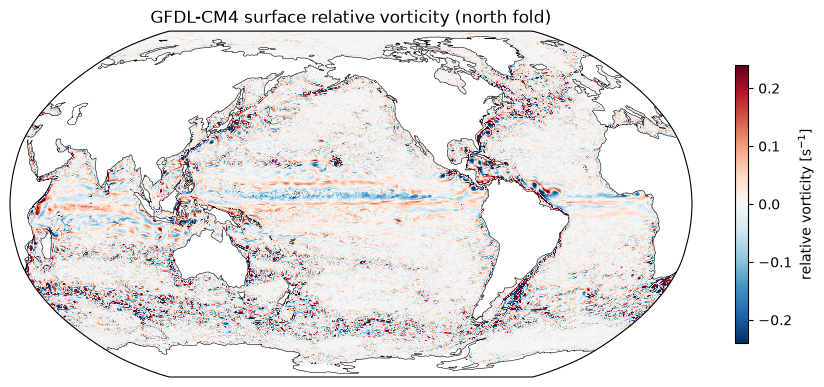

In [3]:
tp.global_vorticity(lon, lat, zeta_fold,
                    title="GFDL-CM4 surface relative vorticity (north fold)")

This is the same map as in the MOM6 example (same projection, colormap and colour
scale), now computed with the fold, and at this scale it looks identical. It
should: the fold only changes the seam row, which is one row out of 1080, lying
over Arctic land at values well below the coastal vorticity that sets the colour
scale.

Maps are not a useful way to look at this. The rest of the notebook works in
logical index space instead, where the seam is just the top row of an array.

## Models put the poles in different places

The `"corner"` above is the pivot: the staggered position the two northern poles
sit on. Models differ here, and the wrong choice misaligns the reflection by half
a cell.

| `fold` value | aliases | pole sits on |
|---|---|---|
| `"center"` | `"t"` | a tracer (T) point |
| `"corner"` | `"f"` | a cell corner (F) point |
| `"u"` | | a zonal-velocity (U) face |
| `"v"` | | a meridional-velocity (V) face |

The [grid topology docs](../grid_topology.md#north-fold) describe how each pivot
maps onto the halo, and how xgcm works out the seam (zonal) axis from the periodic
one.

The rest of the notebook uses three models covering two of these: MOM6 (GFDL-CM4)
and NEMO (IPSL-CM6A-LR) from CMIP6, both `"corner"`, and a 1° Oceananigans/ClimaOcean
snapshot with a `"u"` pivot.

In [4]:
def package(uo, vo, lon, lat, fold, label):
    '''Bundle surface velocities on a common staggered index grid, masking land.'''
    a = lambda x: np.asarray(getattr(x, "values", x), dtype=float)
    uo, vo, lon, lat = a(uo), a(vo), a(lon), a(lat)
    # land = missing, or (where zeros dominate, e.g. immersed boundaries) zero
    def mask_land(z):
        zz = np.where(np.isfinite(z), z, np.nan)
        if np.mean(z == 0) > 0.05:
            zz = np.where(z == 0, np.nan, zz)
        return zz
    uo, vo = mask_land(uo), mask_land(vo)
    ny, nx = uo.shape
    coords = dict(x_c=np.arange(nx), x_f=np.arange(nx), y_c=np.arange(ny), y_f=np.arange(ny))
    u = xr.DataArray(uo, dims=["y_c", "x_f"]).assign_coords(x_f=coords["x_f"], y_c=coords["y_c"])
    v = xr.DataArray(vo, dims=["y_f", "x_c"]).assign_coords(x_c=coords["x_c"], y_f=coords["y_f"])
    return dict(coords=coords, u=u, v=v, lon=lon, lat=lat, fold=fold, label=label,
                ny=ny, nx=nx)


def _grid(coords, edge, ybc):
    '''A Grid on this model's index coords: the seam axis X wraps, and the fold
    axis Y carries either the north-fold spec or a naive boundary (for contrast).'''
    return Grid(xr.Dataset(coords=coords),
                coords={"X": {"center": "x_c", edge: "x_f"},
                        "Y": {"center": "y_c", edge: "y_f"}},
                padding={"X": "periodic", "Y": ybc},
                # these are bare index coordinates, with no Comodo/SGRID attributes
                # for xgcm to parse, so we describe the positions ourselves above
                autoparse_metadata=False)


def speed_centre(m):
    '''sqrt(u^2+v^2) at tracer points; the v->centre interp crosses the fold.'''
    g = _grid(m["coords"], "left", {"fold": m["fold"]})
    uc = g.interp(m["u"], "X")
    vc = g.interp({"Y": m["v"]}, "Y")
    return np.hypot(uc, vc)


def divergence(m):
    '''Horizontal divergence du/dx + dv/dy at the cell centre; the dv/dy term
    crosses the fold, so this exercises `diff` (and the vector fold of v) across
    the seam. Unlike vorticity, divergence is a TRUE SCALAR — invariant under the
    180 degree fold — so it is continuous across the seam and its halo is simply
    the mirrored interior, with no sign subtlety.'''
    g = _grid(m["coords"], "left", {"fold": m["fold"]})
    dudx = g.diff(m["u"], "X")  # X is periodic (the seam axis); let it wrap
    dvdy = g.diff({"Y": m["v"]}, "Y")
    return dudx + dvdy


def fill_seam_vrow(m):
    '''Reconstruct the redundant top row of the meridional velocity ``v``.

    On a tripolar F-fold the top ``v`` faces lie on the seam and come in fold
    pairs ``v(i) = -v(mirror(i))``; the CMIP6 NEMO/MOM6 products keep one half of
    that row and mask the other (the redundant duplicate). xgcm's fold fills
    *halos* from the interior, not interior gaps, so we rebuild this seam row
    here from its fold partner. Without it, interpolating ``v`` to the cell
    centre (e.g. for surface speed) would leave a blank band at the seam. Only
    masked cells whose fold partner is present are filled (a no-op for fields
    that are already complete, e.g. the Oceananigans simulation output).'''
    v = np.asarray(m["v"].values).copy()
    nx = v.shape[1]
    mirror = (-np.arange(nx) - 1) % nx          # seam reflection (seam axis = edge)
    top = v[-1]
    fill = ~np.isfinite(top) & np.isfinite(top[mirror])
    top[fill] = -top[mirror][fill]              # v flips sign across the fold
    m["v"] = m["v"].copy(data=v)

In [5]:
def _cmip6_surface(source_id, version, fold, label):
    inst = {"GFDL-CM4": "NOAA-GFDL", "IPSL-CM6A-LR": "IPSL"}[source_id]
    b = (f"gs://cmip6/CMIP6/CMIP/{inst}/{source_id}/historical/"
         f"r1i1p1f1/Omon/{{var}}/gn/{version}/")

    def s(var):
        d = xr.open_dataset(b.format(var=var), engine="zarr", backend_kwargs=so)
        return d[var].isel(time=0).isel({d[var].dims[1]: 0})

    uo = s("uo").isel(y=slice(0, -1))
    vo = s("vo").isel(y=slice(0, -1))
    g = xr.open_dataset(b.format(var="uo"), engine="zarr", backend_kwargs=so)
    lonn = "lon" if "lon" in g.variables else "nav_lon"
    latn = "lat" if "lat" in g.variables else "nav_lat"
    return package(uo, vo, g[lonn].isel(y=slice(0, -1)).values,
                   g[latn].isel(y=slice(0, -1)).values, fold, label)


def _oceananigans():
    path = pooch.retrieve(url=OCEANANIGANS_URL, known_hash=OCEANANIGANS_MD5,
                          fname="oceananigans_tripolar.nc")
    o = xr.open_dataset(path)
    return package(o["u"].transpose("y_c", "x_f"), o["v"].transpose("y_f", "x_c"),
                   o["lon_cc"].transpose("y_c", "x_c"), o["lat_cc"].transpose("y_c", "x_c"),
                   "u", "Oceananigans (ClimaOcean 1°)")


models = [
    _cmip6_surface("GFDL-CM4", "v20180701", "corner", "MOM6 (GFDL-CM4)"),
    _cmip6_surface("IPSL-CM6A-LR", "v20180803", "corner", "NEMO (IPSL-CM6A-LR)"),
    _oceananigans(),
]
for m in models:          # F-pivot models ship the redundant top v-row masked; rebuild it
    if m["fold"] in ("corner", "f"):
        fill_seam_vrow(m)

### The arrays in index space

Each model's surface speed as it sits in memory: y-index up, x-index across, no
projection. The red line marks the top edge of the array, which is the fold.

The remaining figures all zoom in on that edge. A polar projection distorts the
seam and breaks it up with land, which makes it hard to tell a fold problem from a
plotting problem. In index space the seam is just a horizontal line.

/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-ab8dea27f966b6233/xgcm/grid.py:463: UserWarning: The north-fold (tripolar) boundary condition is experimental. Its API and numerical behavior may change in future releases, and it has not yet been validated across the full range of grid configurations. Please review results carefully and report any issues at https://github.com/xgcm/xgcm/issues.
  warnings.warn(
/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-ab8dea27f966b6233/xgcm/grid.py:463: UserWarning: The north-fold (tripolar) boundary condition is experimental. Its API and numerical behavior may change in future releases, and it has not yet been validated across the full range of grid configurations. Please review results carefully and report any issues at https://github.com/xgcm/xgcm/issues.
  warnings.warn(
/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-ab8dea27f966b6233/xgcm/grid.py:463: UserWarning: The north-fold (tripolar) boundary condition is experimental. It

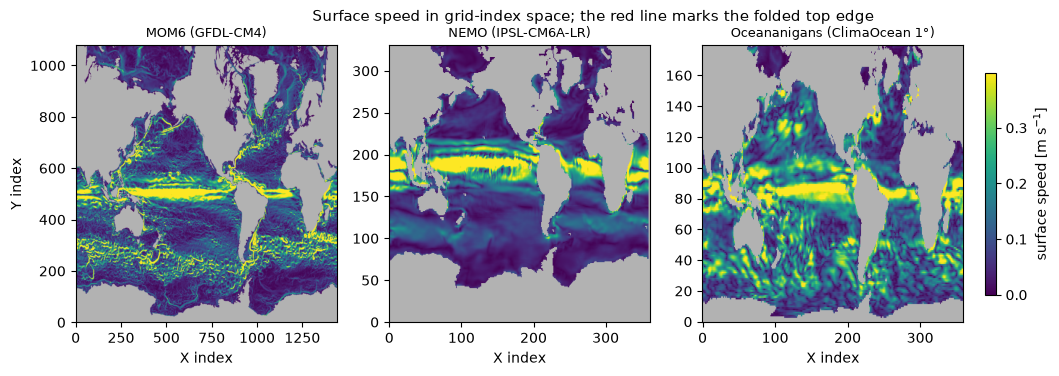

In [6]:
for m in models:
    m["speed"] = speed_centre(m)      # `interp` crosses the fold

tp.index_space_overview(models)

## What the operators pad with

`interp` and `diff` do the padding themselves, which is why the change above was a
single keyword. To see what they padded with, we can call `xgcm.padding.pad`
directly.

This is not something you would normally do, and `pad` is not part of the
documented API. It is useful here because it returns the same halo the operators
build internally, so we can plot a fold halo next to a naive one and compare them
cell by cell. `padding_width={"Y": (0, K)}` asks for `K` rows above the top of the
array.

In [7]:
def _pad_scalar(S, m, K, mode):
    '''K halo rows above a centre scalar field: fold (mirror) or extend (smear).'''
    g = _grid(m["coords"], "right", {"fold": m["fold"]} if mode == "fold" else "extend")
    return np.asarray(pad(S, g, padding_width={"Y": (0, K)}).values)


def _pad_v(m, K, mode, vector):
    '''K halo rows above the v component. vector=True folds it as a vector (the
    180 degree pivot flips its sign); vector=False folds it as a plain scalar. v
    lives at (y_f, x_c); for the vector case u is the other (X) component.'''
    g = _grid(m["coords"], "left", {"fold": m["fold"]} if mode == "fold" else "extend")
    if vector:
        out = pad({"Y": m["v"]}, g, padding_width={"Y": (0, K)}, other_component={"X": m["u"]})
    else:
        out = pad(m["v"], g, padding_width={"Y": (0, K)})
    return np.asarray(out.values)


def _pad_u(m, K, mode, vector):
    '''K halo rows above the u component (zonal), as above. u lives at (y_c, x_f);
    for the vector case v is the other (Y) component.'''
    g = _grid(m["coords"], "left", {"fold": m["fold"]} if mode == "fold" else "extend")
    if vector:
        out = pad({"X": m["u"]}, g, padding_width={"Y": (0, K)}, other_component={"Y": m["v"]})
    else:
        out = pad(m["u"], g, padding_width={"Y": (0, K)})
    return np.asarray(out.values)


# The figures below only draw; everything they show is computed here: the two
# diagnostics, then their halos filled both ways.
K = 6
for m in models:
    m["div"] = divergence(m)                            # `diff` crosses the fold
    for name in ("speed", "div"):
        m[f"{name}_fold"] = _pad_scalar(m[name], m, K, "fold")
        m[f"{name}_naive"] = _pad_scalar(m[name], m, K, "extend")
    for comp, pad_fn in (("v", _pad_v), ("u", _pad_u)):
        m[f"{comp}_scalarfold"] = pad_fn(m, K, "fold", False)
        m[f"{comp}_vectorfold"] = pad_fn(m, K, "fold", True)

tp.attach_windows(models, K=K)   # one shared open-water window per model, for every figure below

/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-ab8dea27f966b6233/xgcm/grid.py:463: UserWarning: The north-fold (tripolar) boundary condition is experimental. Its API and numerical behavior may change in future releases, and it has not yet been validated across the full range of grid configurations. Please review results carefully and report any issues at https://github.com/xgcm/xgcm/issues.
  warnings.warn(
/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-ab8dea27f966b6233/xgcm/grid.py:463: UserWarning: The north-fold (tripolar) boundary condition is experimental. Its API and numerical behavior may change in future releases, and it has not yet been validated across the full range of grid configurations. Please review results carefully and report any issues at https://github.com/xgcm/xgcm/issues.
  warnings.warn(
/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-ab8dea27f966b6233/xgcm/grid.py:463: UserWarning: The north-fold (tripolar) boundary condition is experimental. It

### `interp` across the fold

Surface speed at tracer points near the seam, zoomed to a patch of open water so
that individual cells are visible. Below the black line is the interior; above it
is halo.

The fold halo is the interior reflected about the pole, so it carries real
structure and continues the field. The `'extend'` halo copies the edge value
upwards, giving a vertical streak in every column. The difference between the two
is zero in the interior and nonzero only in the halo.

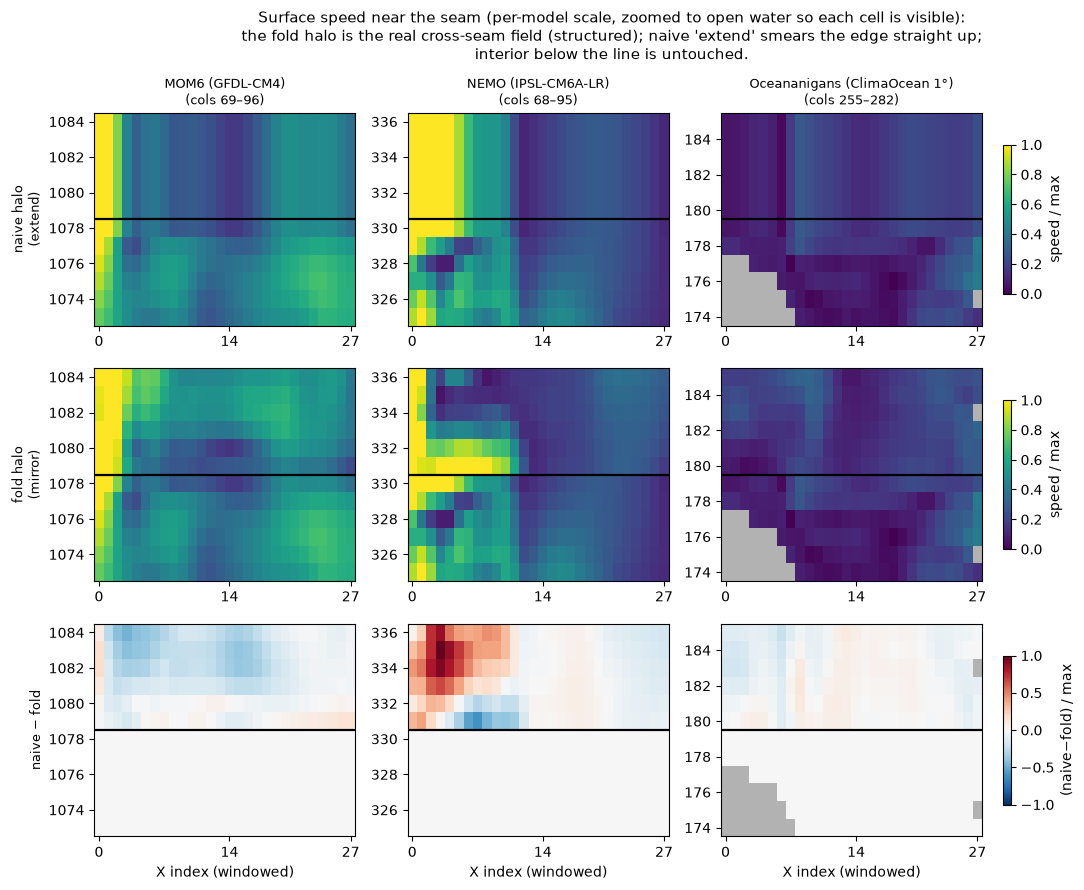

In [8]:
tp.halo_strip(models, "speed_naive", "speed_fold", K=K,
              cbar_label="speed / max",
              suptitle="Surface speed near the seam (per-model scale, zoomed to open water so each "
                       "cell is visible):\nthe fold halo is the real cross-seam field (structured); "
                       "naive 'extend' smears the edge straight up;\ninterior below the line is "
                       "untouched.")

### Scalar and vector folds

This is the sign flip that the `{"X": vo}` dict buys. Each component is folded
twice: once as a plain scalar, and once as a vector, passing its partner through
`other_component`.

Below the seam the two agree. In the halo they have the same magnitude and opposite
sign, for `u` and `v` alike, which is the 180° rotation. Passed a bare array, xgcm
has no way to know it should do this.

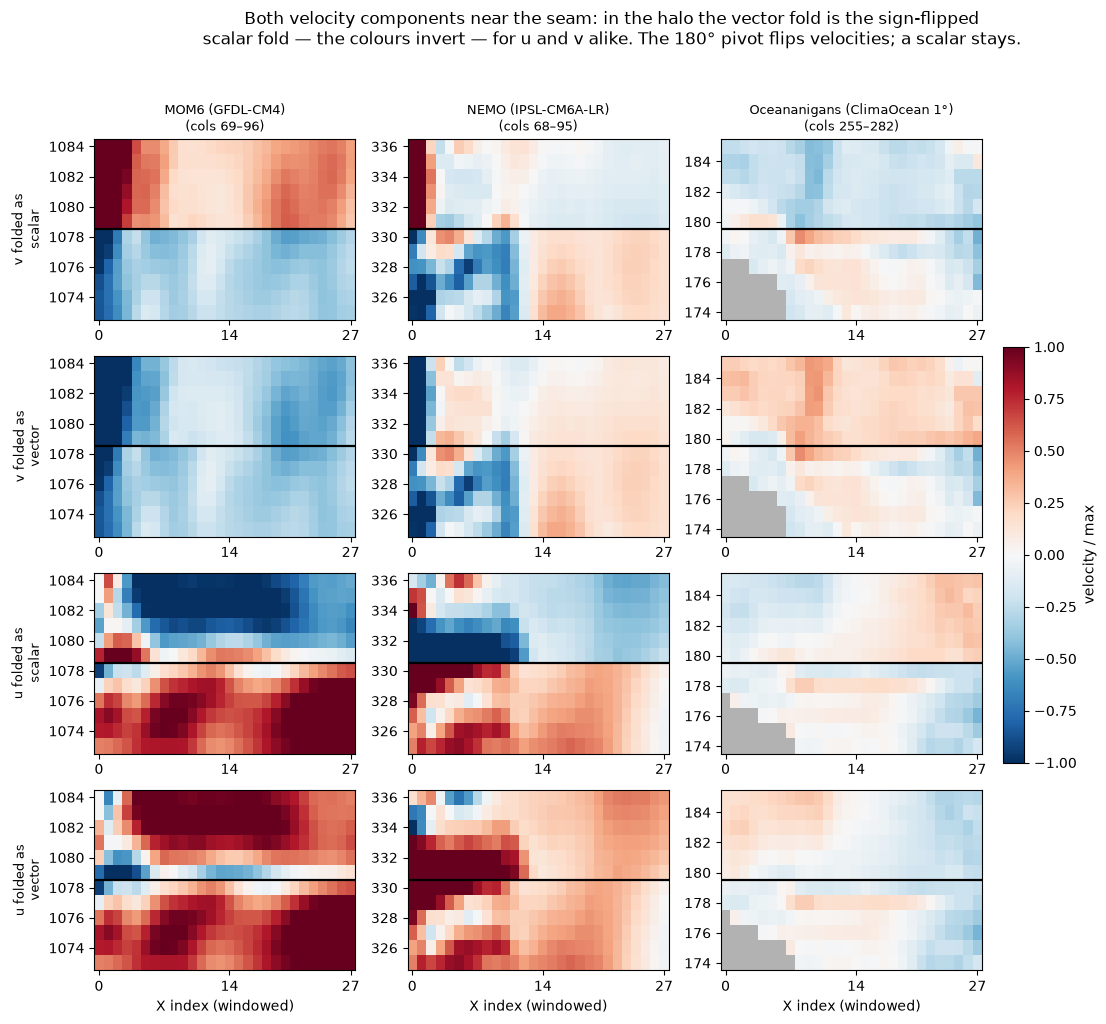

In [9]:
tp.component_strip(models, K=K)

### Continuity across the seam

Following a few ocean columns from the interior, across the seam (dotted) and into
the halo. The fold continues the field, since the seam partner is a real physical
neighbour, while `'extend'` flatlines at the edge value. Columns whose halo runs
into Arctic land simply stop.

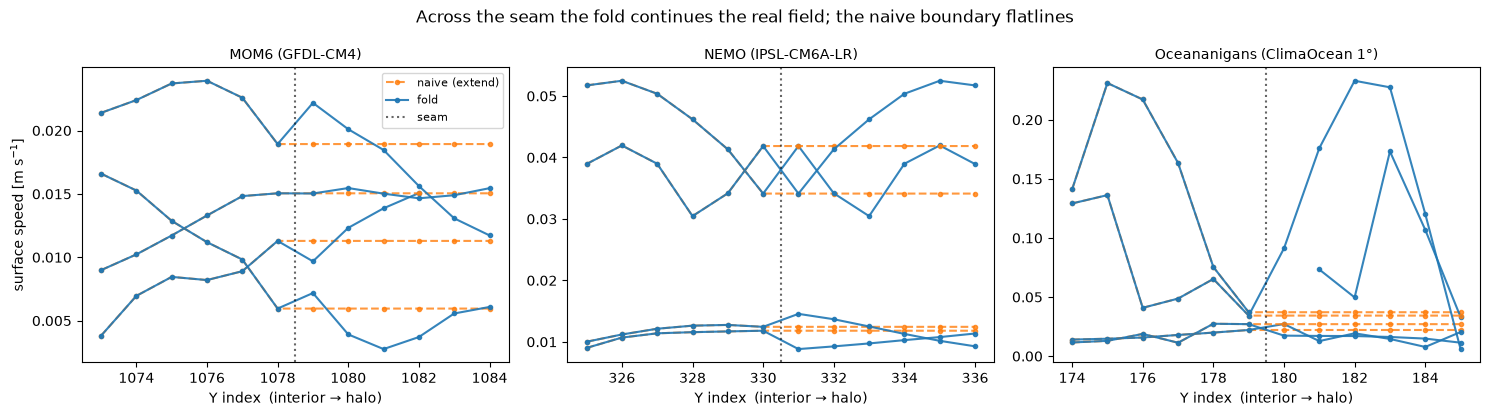

In [10]:
tp.seam_transect(models, K=K)

### `diff` across the fold

The opening figure used `diff` for vorticity. Here it is again for all three
models, using the horizontal divergence $\nabla\!\cdot\mathbf{u} = \partial u/\partial x
+ \partial v/\partial y$, whose $\partial v/\partial y$ term crosses the seam.

Divergence is convenient here because it is a true scalar, invariant under the
fold's rotation, so its halo is just the mirrored interior. Vorticity is a
pseudoscalar and sits at the cell corner, which makes it a good thing to fix but a
more awkward thing to plot.

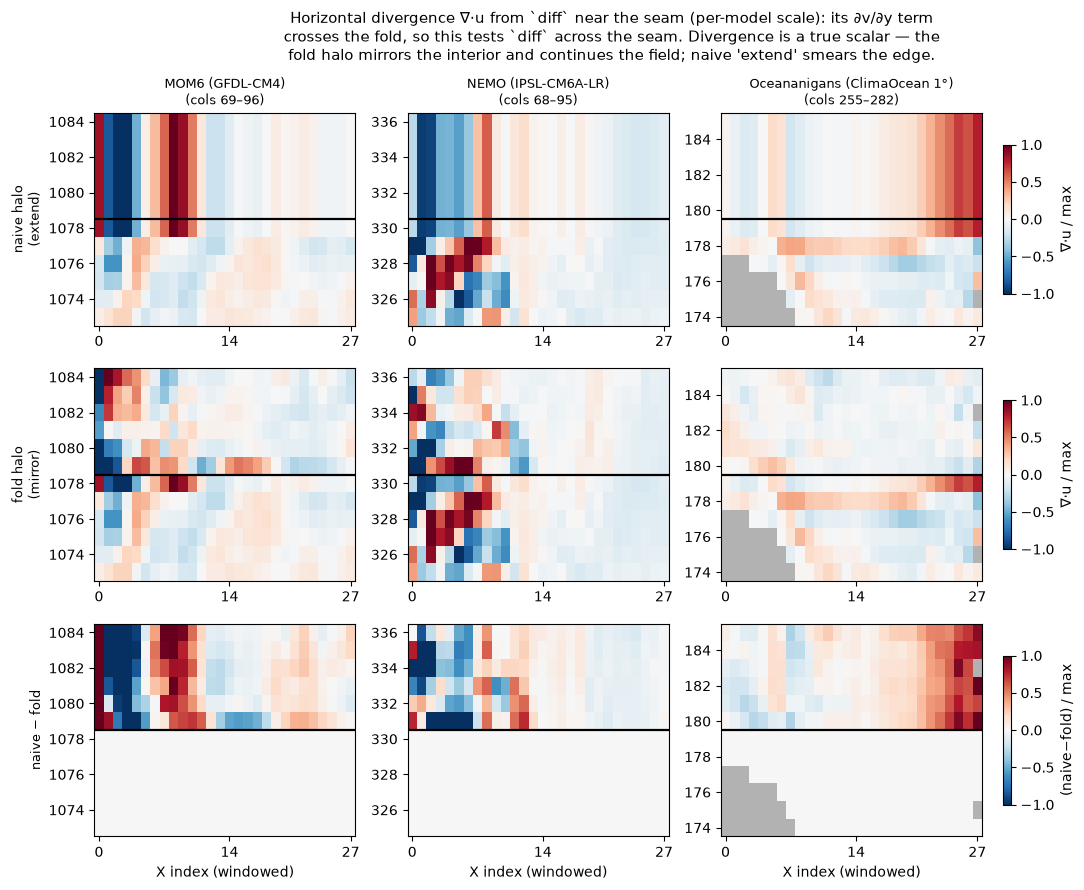

In [11]:
tp.halo_strip(models, "div_naive", "div_fold", K=K, signed=True,
              cbar_label="∇·u / max",
              suptitle="Horizontal divergence ∇·u from `diff` near the seam (per-model scale): its "
                       "∂v/∂y term\ncrosses the fold, so this tests `diff` across the seam. "
                       "Divergence is a true scalar — the\nfold halo mirrors the interior and "
                       "continues the field; naive 'extend' smears the edge.")

## Summary

`padding={"X": "periodic", "Y": {"fold": ...}}` is enough to make the usual
staggered `interp`/`diff`/`derivative` work across the pole, for all three models'
conventions (`"corner"` for MOM6 and NEMO, `"u"` for Oceananigans). Nothing else in
the MOM6 vorticity calculation had to change.

In index space the fold is straightforward:

* the northern halo is the interior reflected about the poles, so a smooth scalar
  such as surface speed continues across the seam, where `'extend'` smears the edge
  value upwards;
* vector components change sign across the seam, provided they are passed as a
  `{axis: array}` dict;
* the interior is untouched, and only the seam row changes.

Since the halo is the reflected interior, structure at the seam is the model's own
field mirrored rather than an artifact of the fold. The grid-scale noise in the
coarse, short-spin-up Oceananigans field mirrors just as faithfully as the smoother
CMIP6 fields do.

See the [grid topology docs](../grid_topology.md#north-fold) for the four pivots
and how the halo is filled, and the [MOM6 example](03_MOM6.ipynb) for more MOM6
recipes.